In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
oct = pd.read_csv('../data/Practice_Level_Crosstab_Oct_24.csv')
nov = pd.read_csv('../data/Practice_Level_Crosstab_Nov_24.csv')
dec = pd.read_csv('../data/Practice_Level_Crosstab_Dec_24.csv')

In [4]:
oct['month'] = '2024-10'
nov['month'] = '2024-11'
dec['month'] = '2024-12'

In [5]:
df = pd.concat([oct, nov, dec], ignore_index=True)

print(f"Total rows: {df.shape[0]:,}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Total rows: 3,089,046
Columns: ['APPOINTMENT_MONTH_START_DATE', 'GP_CODE', 'GP_NAME', 'SUPPLIER', 'PCN_CODE', 'PCN_NAME', 'SUB_ICB_LOCATION_CODE', 'SUB_ICB_LOCATION_NAME', 'HCP_TYPE', 'APPT_MODE', 'NATIONAL_CATEGORY', 'TIME_BETWEEN_BOOK_AND_APPT', 'COUNT_OF_APPOINTMENTS', 'APPT_STATUS', 'month']

First few rows:


,APPOINTMENT_MONTH_START_DATE,GP_CODE,GP_NAME,SUPPLIER,PCN_CODE,PCN_NAME,SUB_ICB_LOCATION_CODE,SUB_ICB_LOCATION_NAME,HCP_TYPE,APPT_MODE,NATIONAL_CATEGORY,TIME_BETWEEN_BOOK_AND_APPT,COUNT_OF_APPOINTMENTS,APPT_STATUS,month
0,01OCT2024,A81001,THE DENSHAM SURGERY,TPP,U89141,STOCKTON PCN,16C,NHS North East and North Cumbria ICB - 16C,GP,Telephone,Planned Clinics,2 to 7 Days,8,Attended,2024-10
1,01OCT2024,A81001,THE DENSHAM SURGERY,TPP,U89141,STOCKTON PCN,16C,NHS North East and North Cumbria ICB - 16C,Other Practice staff,Face-to-Face,Inconsistent Mapping,15 to 21 Days,9,Unknown,2024-10
2,01OCT2024,A81001,THE DENSHAM SURGERY,TPP,U89141,STOCKTON PCN,16C,NHS North East and North Cumbria ICB - 16C,GP,Face-to-Face,Planned Clinics,15 to 21 Days,2,Attended,2024-10
3,01OCT2024,A81001,THE DENSHAM SURGERY,TPP,U89141,STOCKTON PCN,16C,NHS North East and North Cumbria ICB - 16C,GP,Video Conference/Online,Unplanned Clinical Activity,Same Day,65,Attended,2024-10
4,01OCT2024,A81001,THE DENSHAM SURGERY,TPP,U89141,STOCKTON PCN,16C,NHS North East and North Cumbria ICB - 16C,Other Practice staff,Face-to-Face,General Consultation Routine,8 to 14 Days,2,Unknown,2024-10


In [6]:
print(f"Total rows: {df.shape[0]:,}")
print(f"Unique practices: {df['GP_CODE'].nunique():,}")
print(f"Unique ICBs: {df['SUB_ICB_LOCATION_NAME'].nunique()}")
print("\nAppointment status values:")
print(df['APPT_STATUS'].value_counts())
print("\nAppointment mode values:")
print(df['APPT_MODE'].value_counts())
print("\nBooking lead time values:")
print(df['TIME_BETWEEN_BOOK_AND_APPT'].value_counts())
print("\nHCP type values:")
print(df['HCP_TYPE'].value_counts())
print("\nNational category values:")
print(df['NATIONAL_CATEGORY'].value_counts())

Total rows: 3,089,046
Unique practices: 6,184
Unique ICBs: 106

Appointment status values:
APPT_STATUS
Attended    1644366
Unknown      748979
DNA          695701
Name: count, dtype: int64

Appointment mode values:
APPT_MODE
Face-to-Face               1854710
Telephone                   839395
Unknown                     152626
Home Visit                  129064
Video Conference/Online     113251
Name: count, dtype: int64

Booking lead time values:
TIME_BETWEEN_BOOK_AND_APPT
2 to 7 Days             580171
Same Day                547601
8  to 14 Days           497985
1 Day                   428451
15  to 21 Days          399990
22  to 28 Days          329848
More than 28 Days       290970
Unknown / Data Issue     14030
Name: count, dtype: int64

HCP type values:
HCP_TYPE
Other Practice staff    1751282
GP                      1224639
Unknown                  113125
Name: count, dtype: int64

National category values:
NATIONAL_CATEGORY
General Consultation Routine                        

In [7]:
# Filter to only attended and DNA — exclude Unknown
df_clean = df[df['APPT_STATUS'].isin(['Attended', 'DNA'])]

# Overall DNA rate
total = df_clean['COUNT_OF_APPOINTMENTS'].sum()
dna_total = df_clean[df_clean['APPT_STATUS'] == 'DNA']['COUNT_OF_APPOINTMENTS'].sum()
print(f"Total appointments (excl Unknown): {total:,}")
print(f"Total DNA: {dna_total:,}")
print(f"Overall DNA rate: {dna_total/total*100:.1f}%")

# DNA rate by appointment mode
mode_summary = df_clean.groupby(['APPT_MODE', 'APPT_STATUS'])[
    'COUNT_OF_APPOINTMENTS'].sum().unstack(fill_value=0)
mode_summary['dna_rate'] = (
    mode_summary['DNA'] / mode_summary.sum(axis=1) * 100
).round(1)
print("\nDNA rate by appointment mode:")
print(mode_summary[['DNA', 'Attended', 'dna_rate']].sort_values('dna_rate', ascending=False))

# DNA rate by lead time
lead_summary = df_clean.groupby(['TIME_BETWEEN_BOOK_AND_APPT', 'APPT_STATUS'])[
    'COUNT_OF_APPOINTMENTS'].sum().unstack(fill_value=0)
lead_summary['dna_rate'] = (
    lead_summary['DNA'] / lead_summary.sum(axis=1) * 100
).round(1)
print("\nDNA rate by booking lead time:")
print(lead_summary[['dna_rate']].sort_values('dna_rate', ascending=False))

# DNA rate by ICB
icb_summary = df_clean.groupby(['SUB_ICB_LOCATION_NAME', 'APPT_STATUS'])[
    'COUNT_OF_APPOINTMENTS'].sum().unstack(fill_value=0)
icb_summary['dna_rate'] = (
    icb_summary['DNA'] / icb_summary.sum(axis=1) * 100
).round(1)
print("\nTop 10 ICBs by DNA rate:")
print(icb_summary['dna_rate'].sort_values(ascending=False).head(10))

Total appointments (excl Unknown): 91,974,986
Total DNA: 4,631,911
Overall DNA rate: 5.0%

DNA rate by appointment mode:
APPT_STATUS                  DNA  Attended  dna_rate
APPT_MODE                                           
Face-to-Face             3916245  58318921       6.3
Home Visit                 26902    938838       2.8
Telephone                 623389  21419221       2.8
Unknown                    40579   2178735       1.8
Video Conference/Online    24796   4487360       0.5

DNA rate by booking lead time:
APPT_STATUS                 dna_rate
TIME_BETWEEN_BOOK_AND_APPT          
More than 28 Days                9.6
22  to 28 Days                   8.7
15  to 21 Days                   8.6
8  to 14 Days                    8.1
2 to 7 Days                      6.6
1 Day                            4.3
Same Day                         1.8
Unknown / Data Issue             1.7

Top 10 ICBs by DNA rate:
SUB_ICB_LOCATION_NAME
NHS Lancashire and South Cumbria ICB - 00R        7.8
NHS 

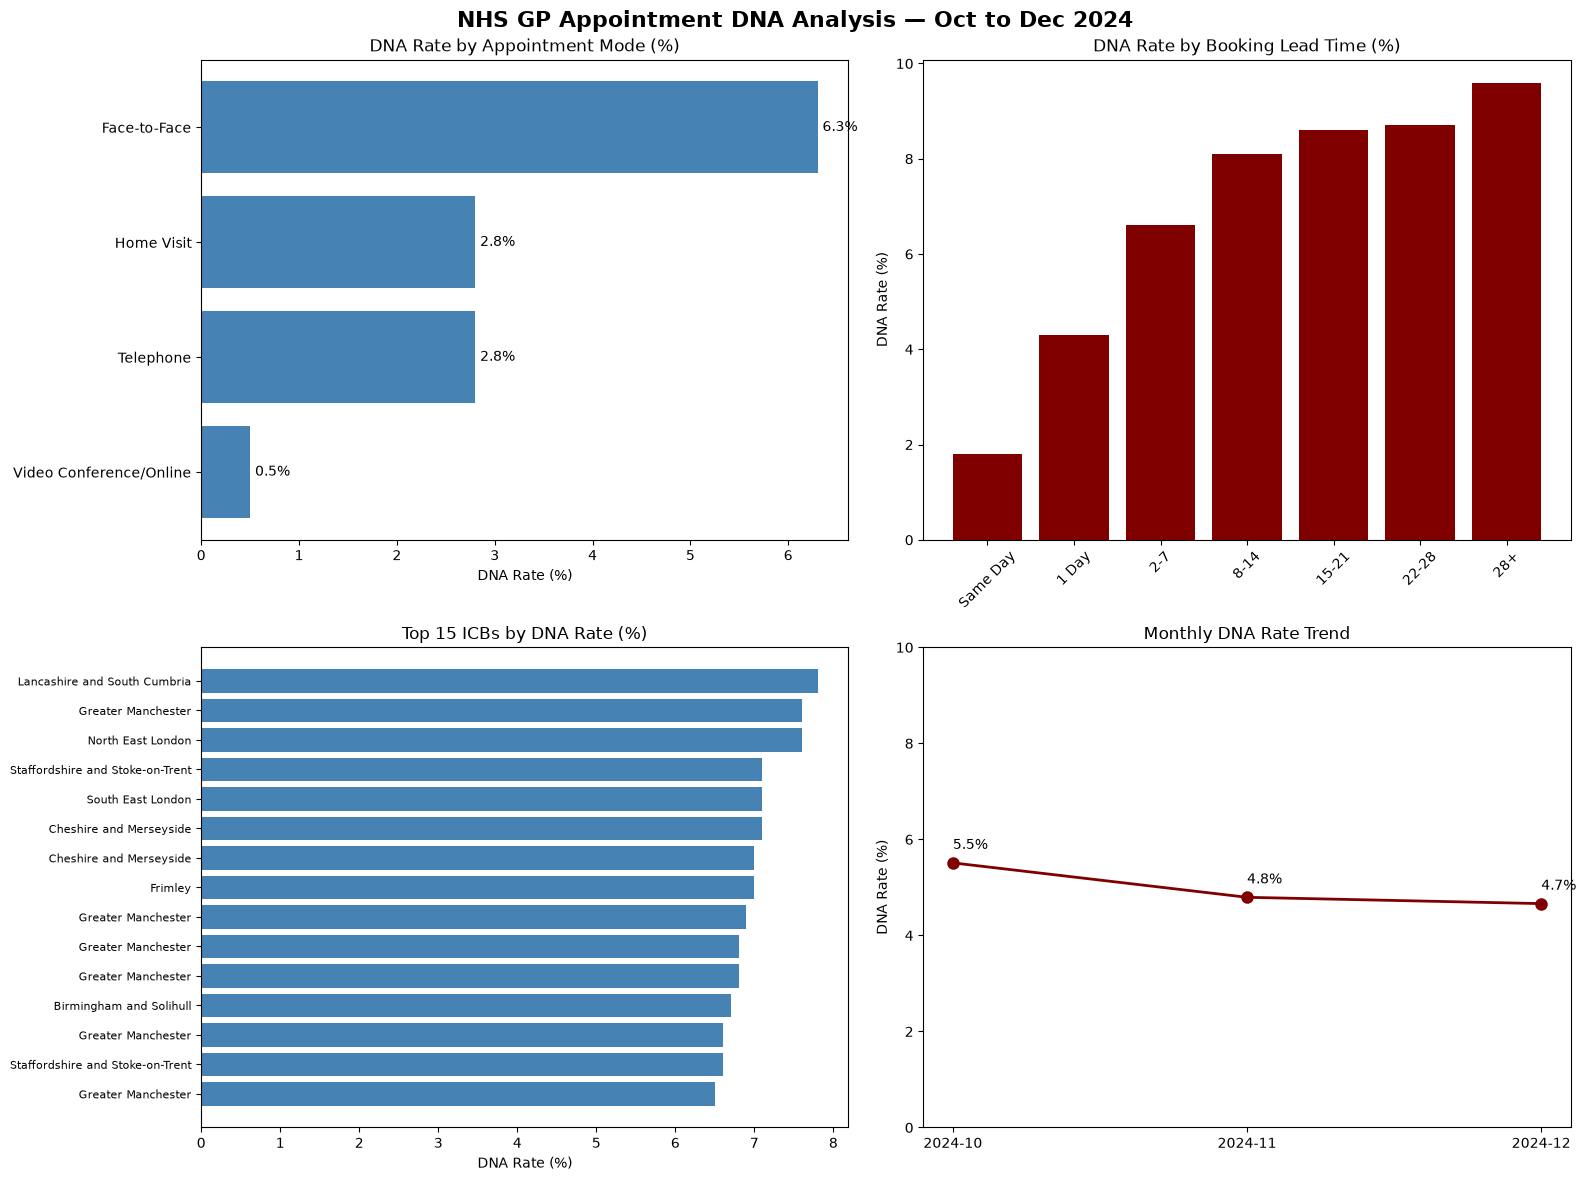

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('NHS GP Appointment DNA Analysis — Oct to Dec 2024', 
             fontsize=16, fontweight='bold')

# DNA rate by mode
mode_plot = mode_summary['dna_rate'].sort_values(ascending=True)
mode_plot = mode_plot[mode_plot.index != 'Unknown']
axes[0,0].barh(mode_plot.index, mode_plot.values, color='steelblue')
axes[0,0].set_title('DNA Rate by Appointment Mode (%)')
axes[0,0].set_xlabel('DNA Rate (%)')
for i, v in enumerate(mode_plot.values):
    axes[0,0].text(v + 0.05, i, f'{v}%', va='center')

# DNA rate by lead time
lead_order = ['Same Day', '1 Day', '2 to 7 Days', '8  to 14 Days',
              '15  to 21 Days', '22  to 28 Days', 'More than 28 Days']
lead_plot = lead_summary.reindex(lead_order)['dna_rate']
axes[0,1].bar(range(len(lead_plot)), lead_plot.values, color='maroon')
axes[0,1].set_xticks(range(len(lead_plot)))
axes[0,1].set_xticklabels(['Same Day', '1 Day', '2-7', '8-14',
                            '15-21', '22-28', '28+'], rotation=45)
axes[0,1].set_title('DNA Rate by Booking Lead Time (%)')
axes[0,1].set_ylabel('DNA Rate (%)')

# Top 15 ICBs
icb_plot = icb_summary['dna_rate'].sort_values(ascending=False).head(15)
axes[1,0].barh(range(len(icb_plot)), icb_plot.values, color='steelblue')
axes[1,0].set_yticks(range(len(icb_plot)))
axes[1,0].set_yticklabels([name.split(' ICB')[0].replace('NHS ', '') 
                            for name in icb_plot.index], fontsize=8)
axes[1,0].invert_yaxis()
axes[1,0].set_title('Top 15 ICBs by DNA Rate (%)')
axes[1,0].set_xlabel('DNA Rate (%)')

# Monthly trend
monthly = df_clean.groupby(['month', 'APPT_STATUS'])[
    'COUNT_OF_APPOINTMENTS'].sum().unstack(fill_value=0)
monthly['dna_rate'] = monthly['DNA'] / monthly.sum(axis=1) * 100
axes[1,1].plot(monthly.index, monthly['dna_rate'], 
               marker='o', color='maroon', linewidth=2, markersize=8)
axes[1,1].set_title('Monthly DNA Rate Trend')
axes[1,1].set_ylabel('DNA Rate (%)')
axes[1,1].set_ylim(0, 10)
for i, (idx, val) in enumerate(monthly['dna_rate'].items()):
    axes[1,1].annotate(f'{val:.1f}%', (idx, val), 
                       textcoords='offset points', xytext=(0,10))

plt.tight_layout()
plt.savefig('../screenshots/eda_findings.png', dpi=150, bbox_inches='tight')
plt.show()